# Words Frequency

In [23]:
# A ENLEVER
from typing import List 
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
NGRAM_RANGE = (1, 1)   # or (1,2) etc.
TOP_K = 30
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
import os
import warnings
import requests
from bs4 import BeautifulSoup
import statsmodels
from statsmodels.stats import proportion
from statsmodels.stats import diagnostic
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import ttest_ind
from io import StringIO
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.preprocessing import StandardScaler

In [24]:
import json, pathlib, csv, re
from collections import Counter


# NLTK setup (robust)
import nltk
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize
except Exception:
    word_tokenize = None

def _ensure_nltk():
    # Try exact resources required by recent NLTK
    for pkg in ["stopwords", "punkt", "punkt_tab"]:
        try:
            nltk.data.find(f"corpora/{pkg}") if pkg=="stopwords" else nltk.data.find(f"tokenizers/{pkg}")
        except LookupError:
            nltk.download(pkg, quiet=True)

_ensure_nltk()

# After ensuring, import again (in case it failed earlier)
from nltk.corpus import stopwords
try:
    from nltk.tokenize import word_tokenize as _wt
    word_tokenize = _wt
except Exception:
    pass

EN_STOP = set(stopwords.words('english'))

# ---- config ----
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
OUTDIR = pathlib.Path("data/GoogleTrends/frequent_words")

# Fallback regex tokenizer (letters only, >=3 chars)
TOKEN_RE = re.compile(r"[A-Za-z]{3,}")

def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field):
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

def tokenize_lower(text: str):
    """Prefer NLTK word_tokenize; fallback to regex if unavailable."""
    if word_tokenize is not None:
        try:
            return [w.lower() for w in word_tokenize(text)]
        except LookupError:
            # If punkt/punkt_tab still missing for some reason, fallback
            return [w.lower() for w in TOKEN_RE.findall(text)]
    else:
        return [w.lower() for w in TOKEN_RE.findall(text)]

def count_tokens_nltk(texts):
    c = Counter()
    for t in texts:
        tokens = tokenize_lower(t)
        # keep only alphabetic tokens, >=3 chars, not in stopwords
        filtered = [w for w in tokens if w.isalpha() and len(w) >= 3 and w not in EN_STOP]
        c.update(filtered)
    return c

def save_counts_csv(counter: Counter, out_path: pathlib.Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["token", "count"])
        for tok, freq in sorted(counter.items(), key=lambda kv: (-kv[1], kv[0])):
            w.writerow([tok, freq])

# ---- run ----
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    counts = count_tokens_nltk(texts)
    outfile = OUTDIR / f"{field}__unigrams_nltk.csv"
    save_counts_csv(counts, outfile)


## Visualize the frequency

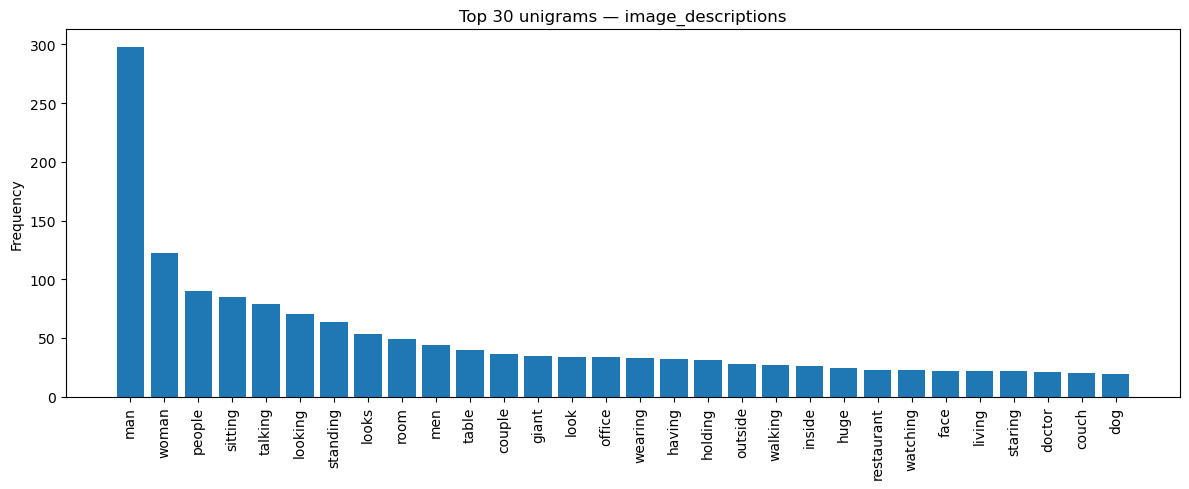

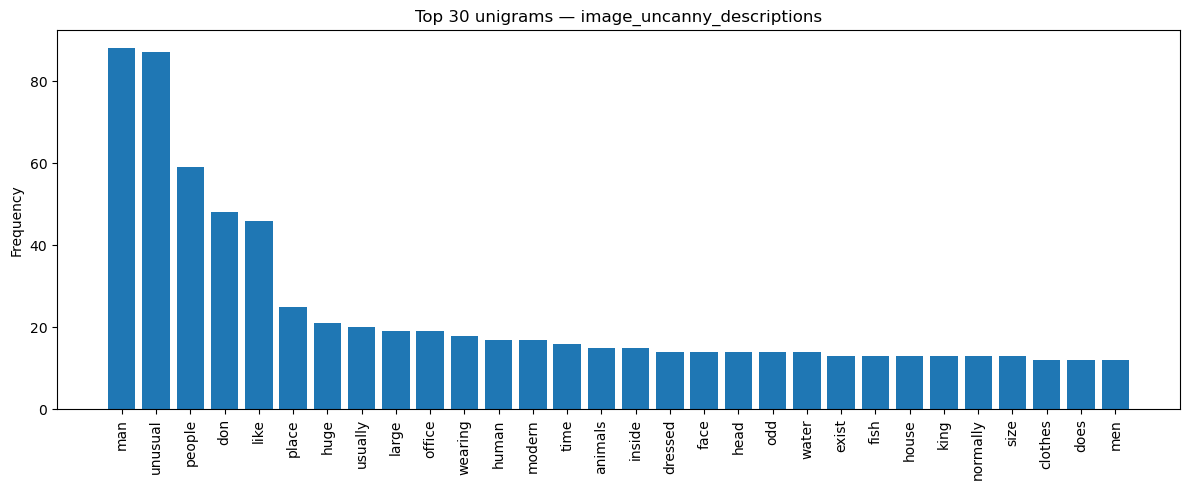

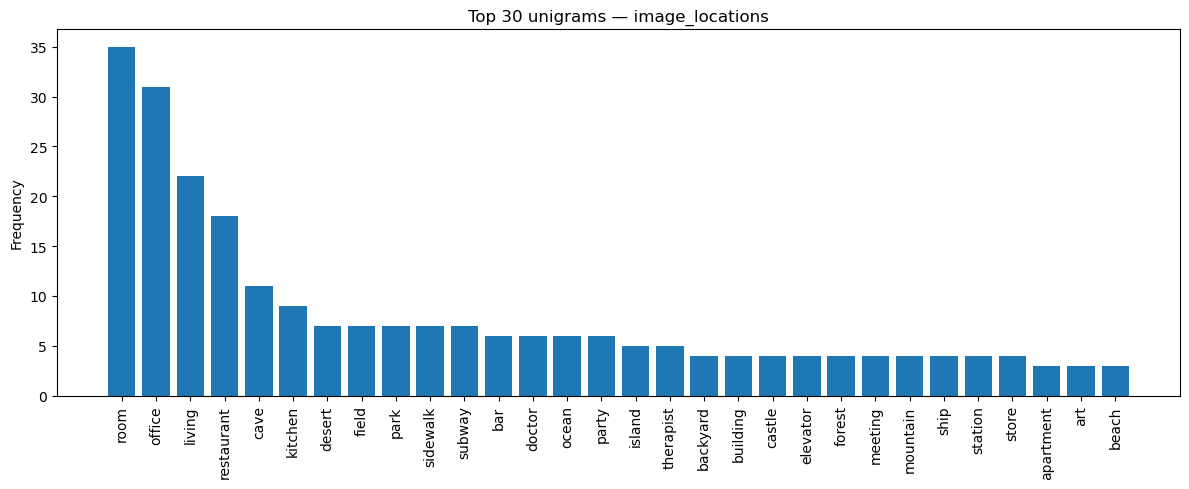

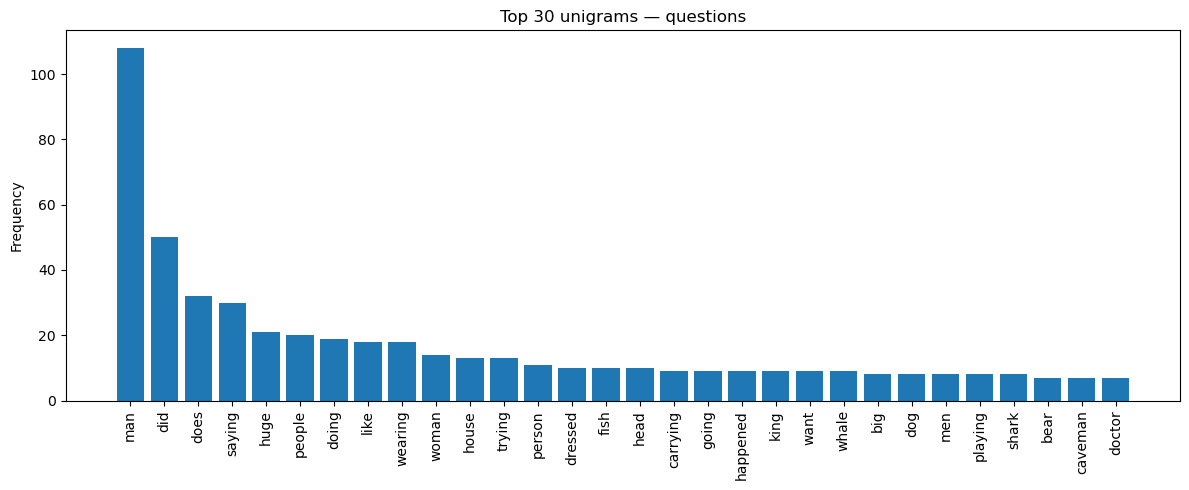

In [25]:
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        # JSONL fallback
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    return out

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    if not texts:
        print(f"[{field}] No texts found, skipping.")
        continue

    vectorizer = CountVectorizer(
        stop_words="english",
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
        ngram_range=NGRAM_RANGE
    )
    X = vectorizer.fit_transform(texts)               # sparse [n_docs, n_vocab]
    counts = np.asarray(X.sum(axis=0)).ravel()        # total counts per vocab term
    vocab = np.array(vectorizer.get_feature_names_out())

    # sort by frequency desc, then term asc
    order = np.lexsort((vocab, -counts))
    top_idx = order[:TOP_K]
    top_terms = vocab[top_idx]
    top_counts = counts[top_idx]

    # Plot one figure per field
    plt.figure(figsize=(12, 5))
    plt.bar(top_terms, top_counts)
    plt.xticks(rotation=90)
    ngram_label = "unigrams" if NGRAM_RANGE == (1,1) else f"{NGRAM_RANGE[0]}-{NGRAM_RANGE[1]}-grams"
    plt.title(f"Top {TOP_K} {ngram_label} — {field}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## Visualize the cluster


=== image_descriptions — KMeans(k=20) top terms per cluster ===
Cluster 00: kitchen, cooking, hazmat, traps, knight, suit, mess, locked, tight, stove
Cluster 01: couch, nearby, dog, room, sitting, hot, man, living, people, monkeys
Cluster 02: cave, caveman, cup, coffee, hole, modern, shop, talking, china, cavepeople
Cluster 03: room, living, sitting, man, going, woman, train, chair, women, throne
Cluster 04: holding, standing, like, face, man, looks, worried, look, cloud, woman
Cluster 05: doctor, patient, gingerbread, king, wrapped, snake, examination, man, office, hospital
Cluster 06: men, walking, carrying, man, woman, street, briefcase, island, building, business
Cluster 07: maze, mouse, lab, mice, scientists, scientist, head, computers, mounted, snail
Cluster 08: fish, bar, bartender, dumpty, humpty, talking, offers, alcohol, plaque, beer
Cluster 09: looking, outside, window, people, man, house, woman, couple, talking, store
Cluster 10: office, psychiatrist, desk, talking, couch,

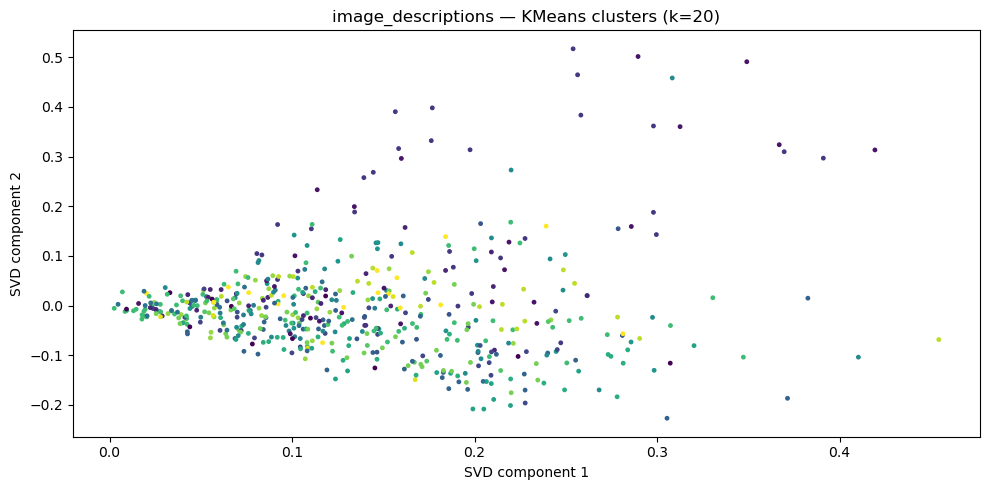


=== image_uncanny_descriptions — KMeans(k=20) top terms per cluster ===
Cluster 00: alive, looking, gingerbread, chefs, hospital, man, doctors, trees, smiling, beast
Cluster 01: people, middle, water, car, build, dog, shouldn, outside, thing, normally
Cluster 02: usually, standing, shark, humans, don, person, stand, close, upright, dragons
Cluster 03: giant, does, lizard, belong, paper, insects, unusual, enormous, sun, donut
Cluster 04: men, dozen, tiny, tubas, possible, bathroom, elevator, look, lay, watching
Cluster 05: earth, pinata, angels, aliens, communicating, carries, globe, playing, lot, oxygen
Cluster 06: large, unusual, lady, halo, balls, aren, unusually, beach, compared, satan
Cluster 07: man, head, mountain, like, lion, cannonballing, pool, piano, looks, diving
Cluster 08: place, really, office, stands, ufos, traps, image, sword, picture, anchor
Cluster 09: modern, woman, times, knight, kitchen, caveman, man, carrying, supposed, mosquitoes
Cluster 10: table, subway, stati

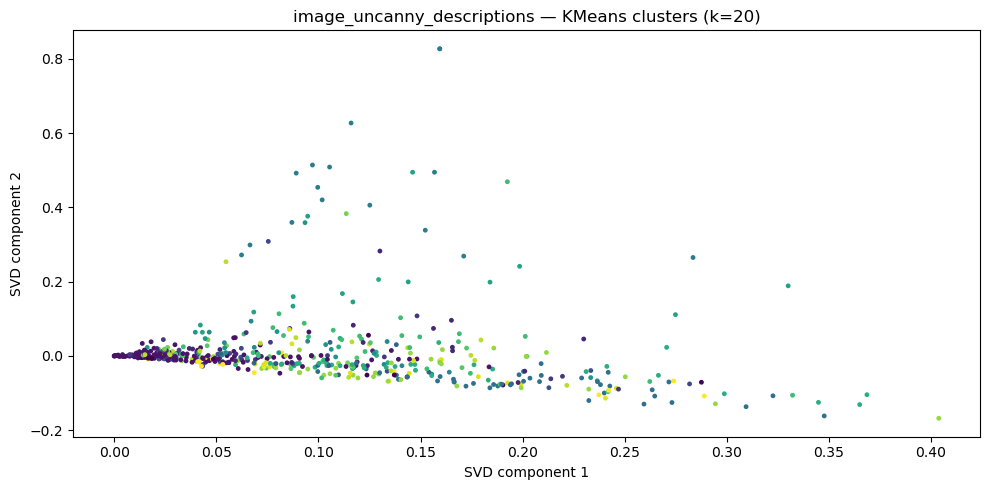


=== image_locations — KMeans(k=20) top terms per cluster ===
Cluster 00: bar, funeral, hard, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 01: field, party, forest, castle, ship, meeting, yard, sea, beach, kingdom
Cluster 02: cave, dwelling, yoga, gallery, hard, hamster, hall, ground, grocery, graveyard
Cluster 03: restaurant, yoga, funeral, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 04: room, living, forest, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 05: desert, middle, funeral, hard, hamster, hall, ground, grocery, graveyard, golf
Cluster 06: backyard, yoga, funeral, hard, hamster, hall, ground, grocery, graveyard, golf
Cluster 07: building, ledge, office, yoga, funeral, hamster, hall, ground, grocery, graveyard
Cluster 08: sidewalk, yoga, forest, hamster, hall, ground, grocery, graveyard, golf, gas
Cluster 09: park, bench, public, heaven, hard, hamster, hall, ground, grocery, graveyard
Cluster 10: subway, train, station, yoga, hard

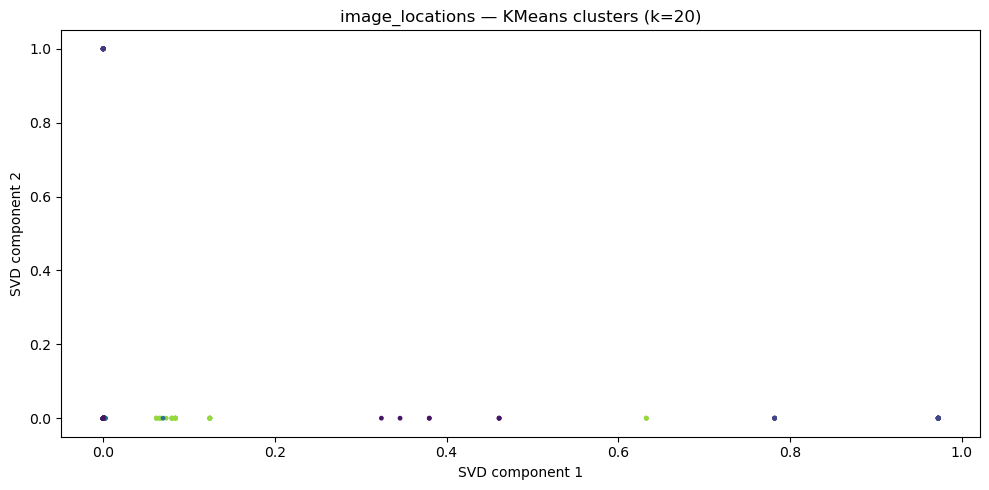


=== questions — KMeans(k=20) top terms per cluster ===
Cluster 00: built, washing, machines, tracks, house, stacked, pair, look, apartment, like
Cluster 01: cowboy, saying, far, falling, fall, faces, face, fable, explorer, explain
Cluster 02: using, office, sword, holding, man, desk, computers, person, embedded, ivs
Cluster 03: big, snail, city, hornets, menu, sword, waiter, head, attacking, gigantic
Cluster 04: wearing, like, dressed, person, dog, armor, horse, suit, propeller, woman
Cluster 05: going, king, color, doctor, building, bear, men, whale, caveman, cooking
Cluster 06: trying, room, living, baseball, hit, playing, hatch, row, man, slanted
Cluster 07: man, gingerbread, head, isn, mountain, dead, happy, cat, small, sandbox
Cluster 08: does, head, say, want, blender, long, man, hair, need, face
Cluster 09: saying, man, woman, caveman, waiter, employee, turtle, hiker, genie, horse
Cluster 10: angry, sheep, lizard, plaque, wolves, fish, experiment, fall, faces, face
Cluster 11: 

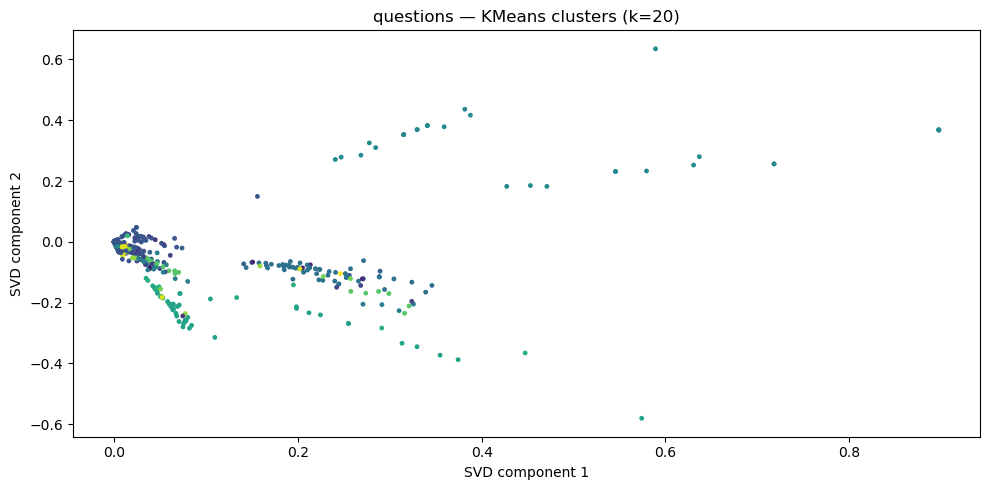

In [26]:
import json, pathlib
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# --- Config ---
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "image_locations", "questions"]
MAX_FEATURES = 5000
DEFAULT_NUM_CLUSTERS = 20
MIN_DOCS_FOR_CLUSTERING = 10      # skip clustering if fewer docs than this
TOP_TERMS_PER_CLUSTER = 10        # how many top words to show per cluster
RANDOM_STATE = 42

# --- Load & normalize JSON ---
def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        if "contests" in obj and isinstance(obj["contests"], list):
            return obj["contests"]
        return [obj]
    raise ValueError("Unsupported JSON structure")

def collect_texts(records, field: str) -> List[str]:
    out = []
    for r in records:
        m = r.get("metadata") or {}
        v = m.get(field) if isinstance(m, dict) else None
        if isinstance(v, list):
            out.extend([s for s in v if isinstance(s, str)])
        elif isinstance(v, str):
            out.append(v)
    # basic cleanup: strip; drop empty
    out = [t.strip() for t in out if isinstance(t, str) and t.strip()]
    return out

def fit_tfidf(texts: List[str]) -> Tuple[TfidfVectorizer, np.ndarray]:
    vec = TfidfVectorizer(
        stop_words="english",
        max_features=MAX_FEATURES,
        token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",  # words with >=3 letters
    )
    X = vec.fit_transform(texts)  # sparse matrix
    return vec, X

def auto_num_clusters(n_docs: int) -> int:
    # heuristic: up to DEFAULT_NUM_CLUSTERS, but never more than n_docs//5 and at least 2
    k = min(DEFAULT_NUM_CLUSTERS, max(2, n_docs // 5))
    return min(k, n_docs) if n_docs >= 2 else 0

def top_terms_per_cluster(kmeans: KMeans, vectorizer: TfidfVectorizer, top_n: int = 10):
    # approximate interpretability: use cluster centers to pick top-weighted features
    terms = vectorizer.get_feature_names_out()
    centers = kmeans.cluster_centers_
    for i, c in enumerate(centers):
        top_idx = np.argsort(c)[::-1][:top_n]
        yield i, [terms[j] for j in top_idx]

def plot_clusters_2d(X_sparse, labels, title: str):
    svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    X_2d = svd.fit_transform(X_sparse)  # works on sparse
    plt.figure(figsize=(10, 5))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, s=6, cmap="viridis")
    plt.title(title)
    plt.xlabel("SVD component 1")
    plt.ylabel("SVD component 2")
    plt.tight_layout()
    plt.show()

# --- Run per field ---
records = load_records(PATH)

for field in FIELDS:
    texts = collect_texts(records, field)
    n_docs = len(texts)
    if n_docs < MIN_DOCS_FOR_CLUSTERING:
        print(f"[{field}] Not enough documents ({n_docs}) — skipping clustering.")
        continue

    vectorizer, X_tfidf = fit_tfidf(texts)
    k = auto_num_clusters(n_docs)
    if k < 2:
        print(f"[{field}] Not enough documents for clustering — skipping.")
        continue

    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_tfidf)
    labels = kmeans.labels_

    # Print top terms per cluster (interpretation)
    print(f"\n=== {field} — KMeans(k={k}) top terms per cluster ===")
    for cid, terms in top_terms_per_cluster(kmeans, vectorizer, TOP_TERMS_PER_CLUSTER):
        print(f"Cluster {cid:02d}: {', '.join(terms)}")

    # Plot 2D clusters
    plot_clusters_2d(X_tfidf, labels, f"{field} — KMeans clusters (k={k})")


## Extract google trend data from march 2016 to september 2023

In [27]:
# === Google Trends for ALL tokens from your four CSVs ===
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
from pathlib import Path
import time

# ---------- CONFIG ----------
CSV_DIR = Path("data/GoogleTrends/frequent_words")
FIELD_PREFIXES = [
    "image_descriptions",
    "image_uncanny_descriptions",
    "image_locations",
    "questions",
]
# We'll read ANY CSV that starts with one of the prefixes (so works with both nltk/non-nltk filenames)
TIMEFRAME = "2016-03-01 2023-09-30"   # March 2016 → September 2023
GEO = "US"                            # set "" for worldwide
BATCH_SIZE = 5                        # Google Trends limit per request
SLEEP_SEC = 2.0                       # politeness delay between calls
RETRY = 2                             # retry per batch on transient errors
MIN_TOKEN_LEN = 3                     # ignore ultra-short tokens
SAVE_PATH = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")
# ----------------------------

def read_tokens_from_csvs(csv_dir: Path, prefixes):
    tokens = []
    for pref in prefixes:
        for p in csv_dir.glob(f"{pref}__*.csv"):
            df = pd.read_csv(p)
            if "token" not in df.columns:
                continue
            toks = (
                df["token"]
                .astype(str)
                .map(str.strip)
                .replace("", np.nan)
                .dropna()
                .tolist()
            )
            tokens.extend(toks)
    # de-duplicate preserving order; enforce min length
    seen = set()
    result = []
    for t in tokens:
        t_low = t.lower()
        if len(t_low) >= MIN_TOKEN_LEN and t_low not in seen:
            seen.add(t_low)
            result.append(t)
    return result

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i : i + n]

# 1) Collect ALL tokens
keywords = read_tokens_from_csvs(CSV_DIR, FIELD_PREFIXES)
if not keywords:
    raise ValueError(f"No tokens found in {CSV_DIR} for prefixes {FIELD_PREFIXES}")

print(f"Total unique keywords to fetch: {len(keywords)}")

# 2) Query Google Trends in batches (≤5)
pytrends = TrendReq(hl="en-US", tz=360)
frames = []
failed_batches = []

for batch in chunks(keywords, BATCH_SIZE):
    ok = False
    err = None
    for attempt in range(1, RETRY + 2):  # first try + retries
        try:
            pytrends.build_payload(kw_list=batch, timeframe=TIMEFRAME, geo=GEO)
            df = pytrends.interest_over_time()
            if "isPartial" in df.columns:
                df = df.drop(columns=["isPartial"])
            frames.append(df)
            ok = True
            break
        except Exception as e:
            err = e
            time.sleep(SLEEP_SEC * attempt)  # exponential-ish backoff
    if not ok:
        failed_batches.append((batch, repr(err)))
    time.sleep(SLEEP_SEC)

# 3) Merge results
if not frames:
    raise RuntimeError("No data returned from Google Trends. (All batches failed.)")

trends_wide = frames[0]
for df in frames[1:]:
    trends_wide = trends_wide.join(df, how="outer")

# Sort by date and fill missing with 0 (optional)
trends_wide = trends_wide.sort_index().fillna(0).astype(int)

# 4) Save single CSV (one column per keyword)
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
trends_wide.to_csv(SAVE_PATH)
print(f"Saved trends to: {SAVE_PATH.resolve()}  with shape {trends_wide.shape}")

# 5) Minimal report on failures (if any)
if failed_batches:
    print("\nSome batches failed (columns missing for these keywords):")
    for batch, e in failed_batches:
        print(f"- {batch} -> {e}")

# 6) Quick sanity peek (first 5 columns & rows)
display(trends_wide.iloc[:5, :5])


ModuleNotFoundError: No module named 'pytrends'

In [28]:
import pandas as pd
from pathlib import Path

# --- Config ---
INPUT_WIDE_CSV = Path("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv")  # adjust if needed
OUTPUT_MEANS_CSV = Path("data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv")

# Use existing trends_wide if present; else load from CSV
if "trends_wide" in globals():
    df = trends_wide.copy()
else:
    # First column is the date index in the saved file
    df = pd.read_csv(INPUT_WIDE_CSV, index_col=0, parse_dates=True)

# Keep only numeric columns (keywords)
num = df.select_dtypes(include="number")

# Compute mean interest per keyword across the full timeframe
means = num.mean(axis=0, skipna=True)

# In case of any accidental duplicate column names, average them
means = means.groupby(level=0).mean()

# Build tidy result and sort
out = (
    means.reset_index()
         .rename(columns={"index": "token", 0: "mean_interest"})
         .sort_values("mean_interest", ascending=False)
         .reset_index(drop=True)
)

out["mean_interest"] = out["mean_interest"].round(3)

# Save
OUTPUT_MEANS_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUTPUT_MEANS_CSV, index=False)


Why do we talk more about men than women in captions, and does that reflect societal attention patterns seen on Google Trends?

Loaded 2263 unique tokens from your dataset.
Trends shape (time x tokens): (91, 2258)

=== Focus groups: dataset counts and ratios ===
- man: 558 (tokens: ['man', 'men'])
- woman: 158 (tokens: ['woman', 'women'])
Ratio man/woman: 3.53

Representative tokens found in Trends: {'man': 'man', 'woman': 'woman'}


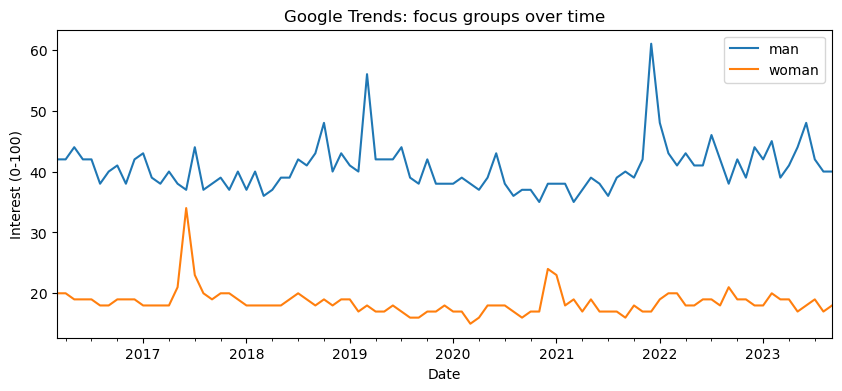


Correlation (ALL TOKENS): Pearson=0.094, Spearman=0.174


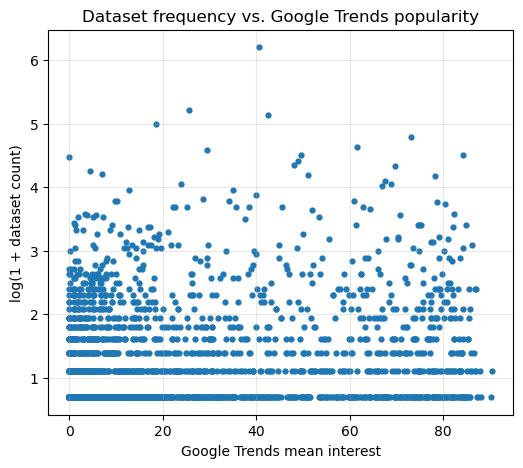


Ordering check (dataset vs. Trends):
- Dataset: man=558 vs woman=158  => a>b
- Trends : man=40.59 vs woman=18.52 => a>b

Time-shape agreement (z-scored): Pearson=-0.037, Kendall tau=0.125


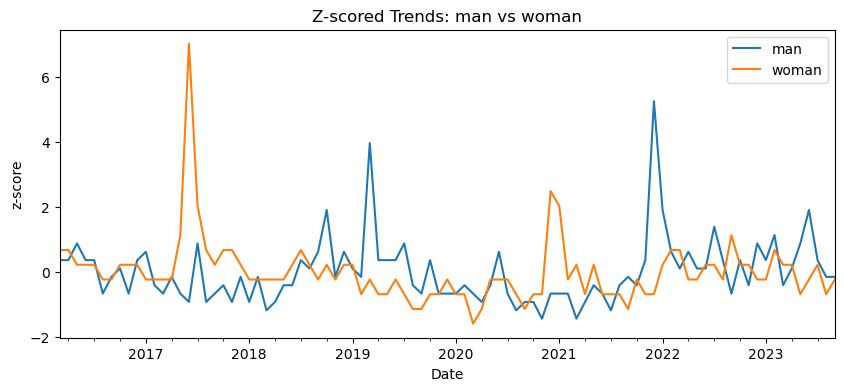

In [33]:
FREQ_FILES = [
    "data/GoogleTrends/frequent_words/image_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_locations__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/image_uncanny_descriptions__unigrams_nltk.csv",
    "data/GoogleTrends/frequent_words/questions__unigrams_nltk.csv",
]


TRENDS_WIDE = "data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv"
TRENDS_MEANS = "data/GoogleTrends/google_trends_means_2016_03_to_2023_09_US.csv"

# focus groups
FOCUS_GROUPS = {
    "man": ["man", "men"],
    "woman": ["woman", "women"],
}

def load_frequencies(freq_files):
    """Load multiple unigram CSVs and sum counts across files """
    frames = []
    for f in freq_files:
        df = pd.read_csv(f)
        if "token" not in df.columns or "count" not in df.columns:
            raise ValueError(f"{f} must have columns: token,count")
        frames.append(df[["token", "count"]].copy())
    big = pd.concat(frames, ignore_index=True)
    big["token"] = big["token"].astype(str)
    agg = big.groupby("token", as_index=False)["count"].sum().sort_values("count", ascending=False)
    return agg

def group_count(freq_df, words):
    """Sum counts for a list of words (focus_groups)."""
    words = [w.lower() for w in words]
    sub = freq_df[freq_df["token"].str.lower().isin(words)]
    return int(sub["count"].sum())

def best_trends_token(trends_df, candidates):
    """ picks the first word from the group that actually exists in the Trends data."""
    for t in candidates:
        if t in trends_df.columns:
            return t
    return None

def zscore_df(df):
    """Z-score columns independently (drop all-NaN columns)."""
    df = df.copy()
    df = df.dropna(axis=1, how="all")
    scaler = StandardScaler(with_mean=True, with_std=True)
    arr = scaler.fit_transform(df.fillna(0.0))
    return pd.DataFrame(arr, index=df.index, columns=df.columns)


freq = load_frequencies(FREQ_FILES)
print(f"Loaded {len(freq)} unique tokens from your dataset.")

trends_wide = pd.read_csv(TRENDS_WIDE, index_col=0, parse_dates=True)
print(f"Trends shape (time x tokens): {trends_wide.shape}")

# Means per token. Otherwise compute from wide:
try:
    trends_means = pd.read_csv(TRENDS_MEANS)
    if not {"token", "mean_interest"}.issubset(trends_means.columns):
        raise ValueError("means file missing required columns")
    trends_means = trends_means[["token", "mean_interest"]].copy()
except Exception:
    # compute if not present
    cols_numeric = trends_wide.select_dtypes(include="number").columns
    trends_means = (
        trends_wide[cols_numeric]
        .mean(axis=0)
        .rename("mean_interest")
        .reset_index()
        .rename(columns={"index": "token"})
    )


print("\n=== Focus groups: dataset counts and ratios ===")
group_counts = {}
for group_name, variants in FOCUS_GROUPS.items():
    c = group_count(freq, variants)
    group_counts[group_name] = c
    print(f"- {group_name}: {c} (tokens: {variants})")

# compute ratio A/B
if len(group_counts) == 2:
    k = list(group_counts.keys())
    a, b = k[0], k[1]
    ra = group_counts[a]
    rb = group_counts[b]
    ratio = (ra / rb) if rb else np.nan
    print(f"Ratio {a}/{b}: {ratio:.2f}")

# Choose one representative token per group that actually exists in trends_wide
rep_tokens = {}
for g, variants in FOCUS_GROUPS.items():
    tok = best_trends_token(trends_wide, variants)
    if tok is not None:
        rep_tokens[g] = tok

if rep_tokens:
    print("\nRepresentative tokens found in Trends:", rep_tokens)
    ax = trends_wide[list(rep_tokens.values())].plot(figsize=(10,4), title="Google Trends: focus groups over time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Interest (0-100)")
    plt.show()
else:
    print("\nNo representative tokens from your focus groups were found in the Trends table.")


# Merge per-token dataset counts with mean Trends interest
merged = freq.merge(trends_means, on="token", how="inner")
merged = merged[merged["mean_interest"].notna()].copy()

# Overall correlations across ALL tokens 
if len(merged) >= 3:
    pear = pearsonr(merged["count"], merged["mean_interest"])[0]
    spear = spearmanr(merged["count"], merged["mean_interest"]).correlation
    print(f"\nCorrelation (ALL TOKENS): Pearson={pear:.3f}, Spearman={spear:.3f}")
else:
    print("\nNot enough tokens overlap between dataset and Trends to compute overall correlation.")

# Scatter plot (log-scale counts to avoid domination by extreme words)
if len(merged) >= 3:
    plt.figure(figsize=(6,5))
    plt.scatter(merged["mean_interest"], np.log1p(merged["count"]), s=12)
    plt.xlabel("Google Trends mean interest")
    plt.ylabel("log(1 + dataset count)")
    plt.title("Dataset frequency vs. Google Trends popularity")
    plt.grid(True, alpha=0.3)
    plt.show()


# If you have exactly 2 groups, check whether ordering agrees: dataset vs trends
if len(FOCUS_GROUPS) == 2 and rep_tokens:
    # dataset ordering
    k = list(FOCUS_GROUPS.keys())
    a, b = k[0], k[1]
    count_a = group_counts.get(a, 0)
    count_b = group_counts.get(b, 0)
    ds_order = np.sign(count_a - count_b)  # +1 if a>b, -1 if a<b, 0 if tie

    # trends ordering using MEAN interest of representative tokens 
    ta = rep_tokens.get(a, None)
    tb = rep_tokens.get(b, None)
    if ta and tb:
        trend_a = trends_wide[ta].mean()
        trend_b = trends_wide[tb].mean()
        tr_order = np.sign(trend_a - trend_b)
        print(f"\nOrdering check (dataset vs. Trends):")
        print(f"- Dataset: {a}={count_a} vs {b}={count_b}  => {'a>b' if ds_order>0 else 'a<b' if ds_order<0 else 'tie'}")
        print(f"- Trends : {a}={trend_a:.2f} vs {b}={trend_b:.2f} => {'a>b' if tr_order>0 else 'a<b' if tr_order<0 else 'tie'}")
    else:
        print("\nCannot compute ordering: representative tokens missing in Trends.")


# correlation between the two time series
if len(rep_tokens) >= 2:
    sub = trends_wide[list(rep_tokens.values())].copy()
    sub_z = zscore_df(sub)   # normalize each series
    if sub_z.shape[1] == 2:
        a_col, b_col = sub_z.columns.tolist()
        pair = sub_z[[a_col, b_col]].dropna()
        tau = kendalltau(pair[a_col], pair[b_col]).correlation
        pear_t = pearsonr(pair[a_col], pair[b_col])[0]
        print(f"\nTime-shape agreement (z-scored): Pearson={pear_t:.3f}, Kendall tau={tau:.3f}")
        pair.plot(figsize=(10,4), title=f"Z-scored Trends: {a_col} vs {b_col}")
        plt.xlabel("Date"); plt.ylabel("z-score"); plt.show()


The pearson correlation is 0.094 which is very close to 0. This mean that there is no strong linear link between dataset frequency and Google Trends interest.
The pearman correlation is 0.174 which means a weak positive tendency. Some of the words that appear more often in the dataset are slightly more popular on Google, but not consistently.
This indicates that the vocabulary used in our dataset does not strongly reflect general public interest.
The dataset therefore captures a specific linguistic or cultural focus, rather than mirroring general online attention.

The scatter plot shows no strong linear pattern between dataset frequency and Google Trends popularity.
Words that are frequent in our corpus are not consistently popular in Google searches.

Are emotionally negative words (fear, death) more frequent during years with global crises (e.g., pandemic)?
Do location words (“New York”, “Paris”) correlate with spikes in Google Trends for those places?

Negative words found: ['fear', 'death', 'sad', 'worry', 'pain', 'suffering', 'panic', 'nervous']
Pandemic words found: []


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


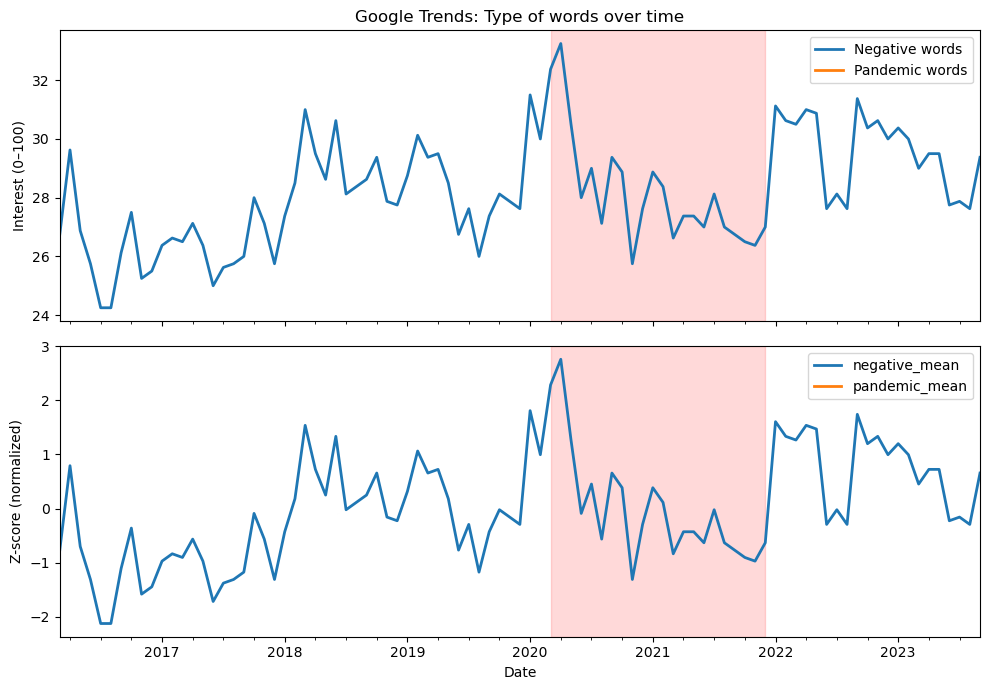


Average interest levels:


,pre_covid,covid,post_covid
negative_mean,27.5625,28.147727,29.565476
pandemic_mean,NaN,NaN,NaN


In [ ]:

trends = pd.read_csv("data/GoogleTrends/google_trends_ALL_tokens_2016_03_to_2023_09_US.csv", index_col=0, parse_dates=True)

NEGATIVE_WORDS = ["fear", "death", "anxiety", "sad", "worry", "crisis", "anger", "pain", "stress", "hate", "war", "depression", "trauma", "suffering", "loss", "grief", "panic", "nervous", "frustration", "helplessness"]
PANDEMIC_WORDS = ["pandemic", "virus", "covid", "quarantine", "lockdown", "vaccine", "mask", "social distancing", "isolation", "outbreak", "immunity", "testing", "symptoms", "healthcare", "hygiene", "sanitizer", "ventilator", "contact tracing", "flatten the curve", "herd immunity"]

neg_available = [w for w in NEGATIVE_WORDS if w in trends.columns]
pand_available = [w for w in PANDEMIC_WORDS if w in trends.columns]

print("Negative words found:", neg_available)
print("Pandemic words found:", pand_available)

# average interest for each group over time
group_series = pd.DataFrame(index=trends.index)
group_series["negative_mean"] = trends[neg_available].mean(axis=1)
group_series["pandemic_mean"] = trends[pand_available].mean(axis=1)

# Optional: z-score normalize to highlight relative changes
scaler = StandardScaler()
group_series_z = pd.DataFrame(scaler.fit_transform(group_series), columns=group_series.columns, index=group_series.index)

# Plot raw and normalized series
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# (1) Raw means
group_series.plot(ax=ax[0], title="Google Trends: Type of words over time", linewidth=2)
ax[0].set_ylabel("Interest (0–100)")
ax[0].legend(["Negative words", "Pandemic words"])
ax[0].axvspan("2020-03", "2021-12", color="red", alpha=0.15, label="Pandemic period")

# (2) Z-scored (to compare shapes)
group_series_z.plot(ax=ax[1], linewidth=2)
ax[1].set_ylabel("Z-score (normalized)")
ax[1].axvspan("2020-03", "2021-12", color="red", alpha=0.15)
ax[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

# Quantitative summary: compare mean interest before/during/after pandemic
pre_covid = group_series.loc["2016-03":"2020-02"].mean()
covid = group_series.loc["2020-03":"2021-12"].mean()
post_covid = group_series.loc["2022-01":"2023-09"].mean()

summary = pd.DataFrame({"pre_covid": pre_covid, "covid": covid, "post_covid": post_covid})
print("\nAverage interest levels:")
display(summary)
